Input Embeddings:

[[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497 0.18340451]]

Attention Weights:

[[0.37375874 0.11373439 0.33710375 0.17540311]
 [0.30050337 0.18229358 0.29603114 0.22117191]
 [0.34464159 0.13464245 0.32827962 0.19243634]
 [0.31362022 0.1663662  0.30402174 0.21599184]]

Attention Output:

[[1.1796727  0.9217873  1.45815851 1.33770808]
 [1.09435999 0.83851284 1.39301108 1.243537  ]
 [1.1515616  0.89314997 1.43845963 1.30643711]
 [1.11065168 0.85384713 1.40560424 1.26208253]]


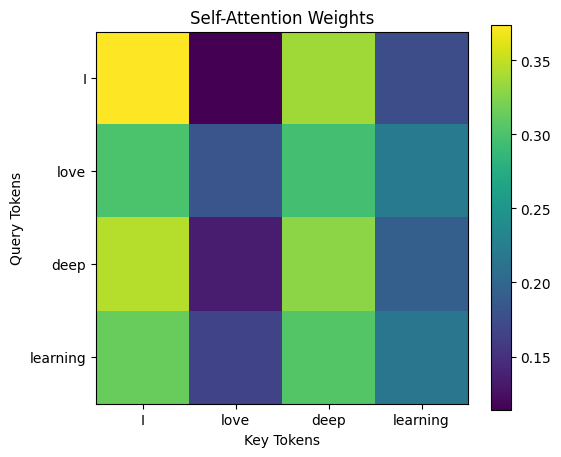

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Input Tokens
# -----------------------------------

tokens = ["I", "love", "deep", "learning"]

# -----------------------------------
# Create Random Embeddings
# -----------------------------------

np.random.seed(42)

embedding_dim = 4

X = np.random.rand(
    len(tokens),
    embedding_dim
)

print("Input Embeddings:\n")
print(X)

# -----------------------------------
# Initialize Weight Matrices
# -----------------------------------

W_Q = np.random.rand(
    embedding_dim,
    embedding_dim
)

W_K = np.random.rand(
    embedding_dim,
    embedding_dim
)

W_V = np.random.rand(
    embedding_dim,
    embedding_dim
)

# -----------------------------------
# Compute Q, K, V
# -----------------------------------

Q = np.dot(X, W_Q)

K = np.dot(X, W_K)

V = np.dot(X, W_V)

# -----------------------------------
# Attention Scores
# -----------------------------------

d_k = K.shape[-1]

scores = np.dot(Q, K.T) / np.sqrt(d_k)

# -----------------------------------
# Softmax Function
# -----------------------------------

def softmax(x):

    exp_x = np.exp(
        x - np.max(x, axis=-1, keepdims=True)
    )

    return exp_x / np.sum(
        exp_x,
        axis=-1,
        keepdims=True
    )

attention_weights = softmax(scores)

print("\nAttention Weights:\n")
print(attention_weights)

# -----------------------------------
# Attention Output
# -----------------------------------

output = np.dot(
    attention_weights,
    V
)

print("\nAttention Output:\n")
print(output)

# -----------------------------------
# Visualization
# -----------------------------------

plt.figure(figsize=(6,5))

plt.imshow(
    attention_weights,
    cmap='viridis'
)

plt.colorbar()

plt.xticks(
    range(len(tokens)),
    tokens
)

plt.yticks(
    range(len(tokens)),
    tokens
)

plt.xlabel("Key Tokens")

plt.ylabel("Query Tokens")

plt.title("Self-Attention Weights")

plt.show()